In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [3]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [4]:
df["Product"]

0       Monitor
1         Phone
2        Tablet
3         Chair
4       Printer
         ...   
1195       Desk
1196    Monitor
1197     Tablet
1198      Chair
1199     Tablet
Name: Product, Length: 1200, dtype: object

In [5]:
df.dtypes


OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object

In [6]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [7]:
df["CouponCode"] = df["CouponCode"].fillna("No coupon code")

In [8]:
df.isnull().sum()


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df =  df.drop(["OrderID","CustomerID","TrackingNumber","Date","ShippingAddress"],axis =1 )

In [11]:
df.columns

Index(['Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'OrderStatus',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product         1200 non-null   object 
 1   Quantity        1200 non-null   int64  
 2   UnitPrice       1200 non-null   float64
 3   PaymentMethod   1200 non-null   object 
 4   OrderStatus     1200 non-null   object 
 5   ItemsInCart     1200 non-null   int64  
 6   CouponCode      1200 non-null   object 
 7   ReferralSource  1200 non-null   object 
 8   TotalPrice      1200 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 84.5+ KB


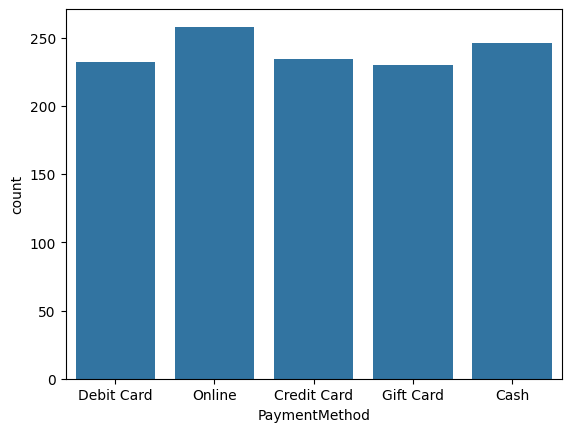

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns 

sns.countplot(data =df , x="PaymentMethod")
plt.show()

<Axes: xlabel='Product', ylabel='Quantity'>

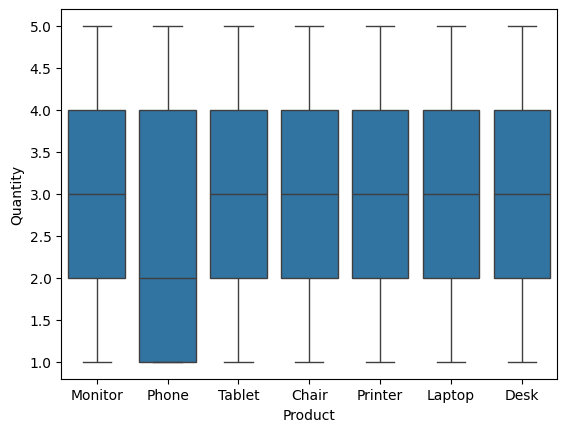

In [14]:
sns.boxplot(x="Product", y= "Quantity",data=df)

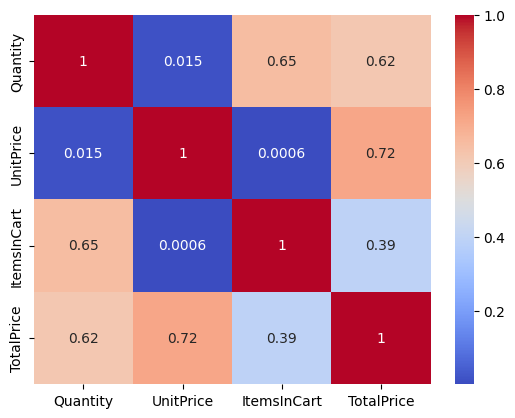

In [15]:
corr =df.select_dtypes(include = "number").corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
columns= ["Product","PaymentMethod","OrderStatus","CouponCode","ReferralSource"]

for col in columns:
    df[col] = le.fit_transform(df[col])

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error ,r2_score
X= df.drop("TotalPrice",axis =1 )
y=df["TotalPrice"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model  = RandomForestRegressor(n_estimators = 100 , random_state = 42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse  = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f"MAE : {mae}")
print(f"MSE : {mse}")
print(f"RMSE : {rmse}")
print(f"r2 : {r2}")



MAE : 8.22057708333342
MSE : 193.60353315062537
RMSE : 13.91414866783539
r2 : 0.9997455360717803


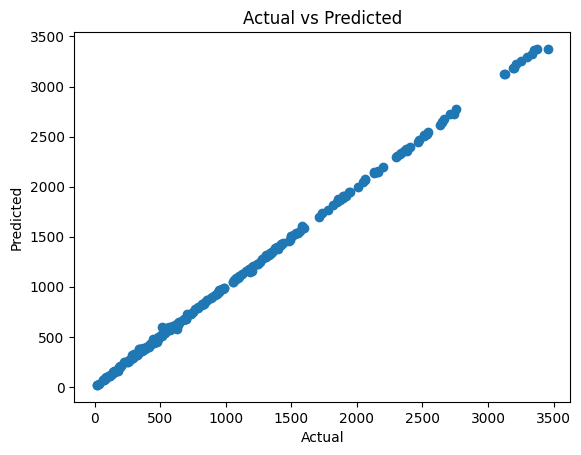

In [20]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()